## ReAct Agent Architecture
- Aim

This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


In [4]:
! uv add arxiv

Resolved 255 packages in 2.31s                                       
⠙ matplotlib==3.11.0                                                            Uninstalled 1 package in 4ms
Installed 2 packages in 3ms                                 
 + arxiv==4.0.0
 - requests==2.34.2
 + requests==2.33.1


In [5]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

import arxiv
from langchain_core.tools import tool


In [6]:
@tool
def arxiv_search(query: str) -> str:
    """
    Search arXiv papers and return title, authors, published date and summary.
    """

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=2,
        sort_by=arxiv.SortCriterion.Relevance,
    )

    output = []

    for paper in client.results(search):
        output.append(
            f"""
Title: {paper.title}

Authors: {", ".join(author.name for author in paper.authors)}

Published: {paper.published.date()}

Summary:
{paper.summary[:500]}

PDF:
{paper.pdf_url}

{'-'*80}
"""
        )

    return "\n".join(output)

In [8]:
print(arxiv_search.invoke("attention all you need"))


Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet

Authors: Luke Melas-Kyriazi

Published: 2021-05-06

Summary:
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a

PDF:
https://arxiv.org/pdf/2105.02723v1

--------------------------------------------------------------------------------


Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme

Authors: Anton Alyakin

Published: 2025-12-03

Summary:
The 2017 paper ''Attention Is All You Need'' introduced 

In [9]:
print(arxiv_search.invoke("Langgraph"))


Title: Agent AI with LangGraph: A Modular Framework for Enhancing Machine Translation Using Large Language Models

Authors: Jialin Wang, Zhihua Duan

Published: 2024-12-05

Summary:
This paper explores the transformative role of Agent AI and LangGraph in advancing the automation and effectiveness of machine translation (MT). Agents are modular components designed to perform specific tasks, such as translating between particular languages, with specializations like TranslateEnAgent, TranslateFrenchAgent, and TranslateJpAgent for English, French, and Japanese translations, respectively. These agents leverage the powerful semantic capabilities of large language models (LLMs), 

PDF:
https://arxiv.org/pdf/2412.03801v1

--------------------------------------------------------------------------------


Title: Exploration of LLM Multi-Agent Application Implementation Based on LangGraph+CrewAI

Authors: Zhihua Duan, Jialin Wang

Published: 2024-11-27

Summary:
With the rapid development of la

In [10]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

wiki.name

'wikipedia'

In [12]:
print(wiki.invoke("Michel jackson"))

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [16]:
from pprint import pprint

result = wiki.invoke("Michael Jackson")

pprint(result)


('Page: Michael Jackson\n'
 'Summary: Michael Joseph Jackson (August 29, 1958 – June 25, 2009) was an '
 'American singer, songwriter, dancer, and philanthropist. Known as the "King '
 'of Pop", he is widely regarded as one of the most culturally significant '
 'figures of the 20th century. His musical achievements broke American racial '
 'barriers and made him a dominant global figure. Through his songs, music '
 'videos, concerts, and fashion, he transformed visual performance in popular '
 'music, popularizing street danc')


In [17]:
print(result)

Page: Michael Jackson
Summary: Michael Joseph Jackson (August 29, 1958 – June 25, 2009) was an American singer, songwriter, dancer, and philanthropist. Known as the "King of Pop", he is widely regarded as one of the most culturally significant figures of the 20th century. His musical achievements broke American racial barriers and made him a dominant global figure. Through his songs, music videos, concerts, and fashion, he transformed visual performance in popular music, popularizing street danc


In [18]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="QUANTAMVECTOR_CLASS"




In [19]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv_search,wiki,add,multiply,divide]

In [20]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/var/folders/m8/jv_qd8md6_n84v8zcshwvjm40000gn/T/ipykernel_64314/3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [22]:
tavily.invoke("can you tell when is latest spider man movie coming out..? in july 2026")

[{'title': "'Spider-Man: Brand New Day' Trailer and Movie Tickets Go ...",
  'url': 'https://www.marvel.com/articles/movies/spider-man-brand-new-day-trailer-and-movie-tickets-go-live',
  'content': "Movies\n\nPublished June 17, 2026\n\n# ‘Spider-Man: Brand New Day’ Trailer and Movie Tickets Go Live\n\n## Watch the latest trailer for ‘Spider-Man: Brand New Day’ and grab tickets for the movie, releasing exclusively in theaters July 31, 2026.\n\nBY Marvel\n\nThe world may have forgotten Peter Parker, but he hasn’t forgotten them.\n\nThat’s right Web-Heads, the latest trailer for Spider-Man: Brand New Day just landed, live from Amsterdam! Following the press tour kicking off in Madrid earlier this week, Tom Holland and Zendaya announced that tickets for Spidey’s next theatrical adventure are on sale now. Get your tickets for Spider-Man: Brand New Dayat  watch the latest trailer for the movie below! [...] #### Grab your tickets for Spider-Man: Brand New Daytoday, swinging exclusively into t

In [23]:
tools=[arxiv_search,wiki,add,multiply,divide]

In [24]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

/Users/manojkrishnappa/github/Quantam-vector-Rag-Masterclass/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
llm.invoke("can you tell when is latest spider man movie coming out..? in july 2026")

AIMessage(content='I’m sorry, but I don’t have information about movie releases that are scheduled after my knowledge cutoff in\u202fJune\u202f2024. For the most accurate and up‑to‑date details on any Spider‑Man film slated for July\u202f2026, I recommend checking the official Marvel/Spider‑Man websites, reputable entertainment news outlets, or the movie’s social‑media channels as the date approaches.', additional_kwargs={'reasoning_content': 'The user asks: "can you tell when is latest spider man movie coming out..? in July 2026". They want release date info. This is a request for up-to-date info. The user asks about future release date of latest Spider-Man movie, presumably as of July 2026. We need to check if we have knowledge cutoff 2024-06, so we cannot guarantee knowledge about releases after that. We must respond with the policy: we can provide info up to cutoff, and say we don\'t have info beyond. We can suggest checking official sources. So comply.'}, response_metadata={'token

In [26]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([HumanMessage(content=f"can you tell when is latest spider man movie coming out..? in july 2026")]).tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Spider-Man film release July 2026'},
  'id': 'fc_5531e984-61ea-45bd-99d6-bddba92e19e8',
  'type': 'tool_call'}]

In [27]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

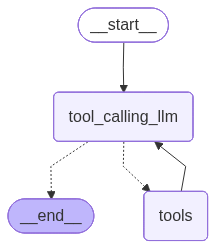

In [28]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
messages=graph.invoke({"messages":HumanMessage(content="can you tell when is latest spider man movie coming out..? in july 2026,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

can you tell when is latest spider man movie coming out..? in july 2026,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fc_d3f850c1-e67a-4a82-8c3f-dc430cdfcba3)
 Call ID: fc_d3f850c1-e67a-4a82-8c3f-dc430cdfcba3
  Args:
    query: upcoming Spider-Man film 2026 release date
================================= Tool Message =================================
Name: wikipedia

Page: Spider-Man: Beyond the Spider-Verse
Summary: Spider-Man: Beyond the Spider-Verse is an upcoming American animated superhero film based on Marvel Comics featuring the character Miles Morales / Spider-Man. Directed by Bob Persichetti and Justin K. Thompson from a screenplay by the writing team of Phil Lord and Christopher Miller alongside David Callaham, it is the direct sequel to Spider-Man: Across the Spider-Verse (2023) and the final install

In [30]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to **learn from data** and improve their performance on a task without being explicitly programmed for every possible situation.

### Core Idea
- **Data‑driven**: Instead of writing explicit rules, you feed the system examples (data) and let it infer patterns.
- **Generalization**: The goal is to build a model that performs well not only on the data it has seen (training data) but also on new, unseen data (test or real‑world data).

### Typical Workflow
1. **Collect Data** – Gather labeled (supervised) or unlabeled (unsupervised) examples.
2. **Preprocess** – Clean, normalize, and transform the data into a suitable format.
3. **Choose a Model** – 